In [37]:
import sys
import os
import numpy as  np
sys.path.append(os.path.abspath(os.path.join('..')))
import pandas as pd
from src.data.loader import load_raw_data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [24]:
df = load_raw_data("../data/raw/db.csv")

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['day'] = df['Date'].dt.day

df_expenses = df[df['Type'] == 'Expenses'].copy()

gasto_10d = df_expenses[df_expenses['day'] <= 10].groupby(['year', 'month']).agg({
    'Amount': 'sum',
    'Description': 'count'  # Frecuencia de gasto
}).reset_index()

gasto_total = df_expenses.groupby(['year', 'month'])['Amount'].sum().reset_index()
df_ml = pd.merge(gasto_10d, gasto_total, on=['year', 'month'], suffixes=('_10d', '_total'))
df_ml.columns = ['year', 'month', 'init_spent_month', 'freq_init_month', 'total_final_month']

# escalado de datos (para que el Clustering funcione bien)
scaler = StandardScaler()
df_ml[['spent_std', 'freq_std']] = scaler.fit_transform(df_ml[['init_spent_month', 'freq_init_month']])

df_ml.head()

,year,month,init_spent_month,freq_init_month,total_final_month,spent_std,freq_std
0,2010,2,16.62,2,77.85,-0.975850,-1.237878
1,2010,3,86.17,4,288.42,-0.203098,-0.131811
2,2010,4,15.51,2,133.17,-0.988183,-1.237878
3,2010,5,93.51,5,168.51,-0.121545,0.421222
4,2010,6,57.14,3,266.54,-0.525643,-0.684845


In [25]:
# 1. Creamos rasgos: Gasto total 10d y número de transacciones en esos 10d
df_clust = df_expenses[df_expenses['day'] <= 10].groupby(['year', 'month']).agg({
    'Amount': 'sum',
    'Description': 'count'
}).reset_index()

# 2. Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust[['Amount', 'Description']])


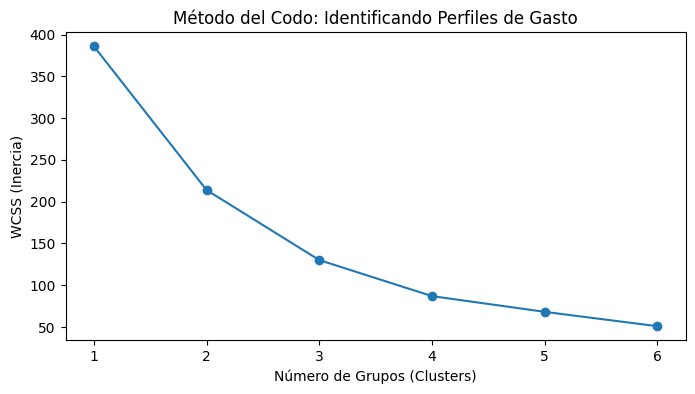

In [26]:
wcss = []
for i in range(1, 7):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), wcss, marker='o')
plt.title('Método del Codo: Identificando Perfiles de Gasto')
plt.xlabel('Número de Grupos (Clusters)')
plt.ylabel('WCSS (Inercia)')
plt.show()

In [30]:
# 1. Aplicamos K-Means con los nombres de tus columnas escaladas
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_ml['perfil_num'] = kmeans.fit_predict(df_ml[['spent_std', 'freq_std']])

resumen = df_ml.groupby('perfil_num')['init_spent_month'].mean().sort_values().index

mapeo = {
    resumen[0]: "saver",
    resumen[1]: "moderate",
    resumen[2]: "risk"
}
df_ml['perfil_nombre'] = df_ml['perfil_num'].map(mapeo)

print(df_ml[['init_spent_month', 'perfil_nombre']].head())

   init_spent_month perfil_nombre
0             16.62         saver
1             86.17         saver
2             15.51         saver
3             93.51      moderate
4             57.14         saver


In [31]:
X = df_ml[['init_spent_month', 'freq_init_month', 'perfil_num']]
y = df_ml['total_final_month']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"--- MÉTRICAS REALES ---")
print(f"Error Medio: {mae:.2f}€ (MAE)")
print(f"Error Porcentual: {mape:.2f}% (MAPE)")
print(f"Explicación del modelo (R2): {r2:.4f}")

--- MÉTRICAS REALES ---
Error Medio: 96.24€ (MAE)
Error Porcentual: 52.69% (MAPE)
Explicación del modelo (R2): 0.0926


: 